In [1]:
#Importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [2]:
# mounting from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/ML Project/Insurance_Fraud_Dataset_100K_Realistic.xlsx"

df = pd.read_excel(file_path)

In [4]:
df.head()

,claim_id,customer_age,months_as_customer,previous_claims,previous_fraud_history,insured_sex,insured_education_level,insured_occupation,insured_relationship,policy_state,...,bodily_injuries,witnesses,police_report_available,injury_claim,property_claim,vehicle_claim,claim_amount,auto_make,auto_model,auto_year
0,CLM000001,21,88,2,0,MALE,Associate,Teacher,Child,TX,...,0,0,YES,1750,12723,36140,50613,Honda,B,2012
1,CLM000002,68,124,0,0,MALE,PhD,Technician,Other,TX,...,2,0,YES,1704,10297,23509,35510,Tesla,C,2013
2,CLM000003,39,23,2,0,FEMALE,High School,Doctor,Married,CA,...,1,0,YES,26017,11313,2068,39398,Toyota,B,2022
3,CLM000004,30,131,0,0,FEMALE,High School,Engineer,Parent,OH,...,1,2,YES,14274,311,8118,22703,Toyota,B,2021
4,CLM000005,22,100,5,0,FEMALE,Associate,Technician,Child,NY,...,1,5,YES,27525,20862,4745,53132,Toyota,C,2022


In [5]:
#checking missing values
df.isnull().sum()

,0
claim_id,0
customer_age,0
months_as_customer,0
previous_claims,0
previous_fraud_history,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_relationship,0
policy_state,0


In [6]:
#handling missing values by filling with "Unknown"
df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

In [7]:
df.head()

,claim_id,customer_age,months_as_customer,previous_claims,previous_fraud_history,insured_sex,insured_education_level,insured_occupation,insured_relationship,policy_state,...,bodily_injuries,witnesses,police_report_available,injury_claim,property_claim,vehicle_claim,claim_amount,auto_make,auto_model,auto_year
0,CLM000001,21,88,2,0,MALE,Associate,Teacher,Child,TX,...,0,0,YES,1750,12723,36140,50613,Honda,B,2012
1,CLM000002,68,124,0,0,MALE,PhD,Technician,Other,TX,...,2,0,YES,1704,10297,23509,35510,Tesla,C,2013
2,CLM000003,39,23,2,0,FEMALE,High School,Doctor,Married,CA,...,1,0,YES,26017,11313,2068,39398,Toyota,B,2022
3,CLM000004,30,131,0,0,FEMALE,High School,Engineer,Parent,OH,...,1,2,YES,14274,311,8118,22703,Toyota,B,2021
4,CLM000005,22,100,5,0,FEMALE,Associate,Technician,Child,NY,...,1,5,YES,27525,20862,4745,53132,Toyota,C,2022


In [8]:
# Re-checking missing values if any of them left or not
df.isnull().sum()

,0
claim_id,0
customer_age,0
months_as_customer,0
previous_claims,0
previous_fraud_history,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_relationship,0
policy_state,0


In [9]:
# Checking duplicates if any
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   claim_id                     100000 non-null  object
 1   customer_age                 100000 non-null  int64 
 2   months_as_customer           100000 non-null  int64 
 3   previous_claims              100000 non-null  int64 
 4   previous_fraud_history       100000 non-null  int64 
 5   insured_sex                  100000 non-null  object
 6   insured_education_level      100000 non-null  object
 7   insured_occupation           100000 non-null  object
 8   insured_relationship         100000 non-null  object
 9   policy_state                 100000 non-null  object
 10  policy_csl                   100000 non-null  object
 11  policy_deductable            100000 non-null  int64 
 12  policy_annual_premium        100000 non-null  int64 
 13  umbrella_limit 

In [11]:
df.head()

,claim_id,customer_age,months_as_customer,previous_claims,previous_fraud_history,insured_sex,insured_education_level,insured_occupation,insured_relationship,policy_state,...,bodily_injuries,witnesses,police_report_available,injury_claim,property_claim,vehicle_claim,claim_amount,auto_make,auto_model,auto_year
0,CLM000001,21,88,2,0,MALE,Associate,Teacher,Child,TX,...,0,0,YES,1750,12723,36140,50613,Honda,B,2012
1,CLM000002,68,124,0,0,MALE,PhD,Technician,Other,TX,...,2,0,YES,1704,10297,23509,35510,Tesla,C,2013
2,CLM000003,39,23,2,0,FEMALE,High School,Doctor,Married,CA,...,1,0,YES,26017,11313,2068,39398,Toyota,B,2022
3,CLM000004,30,131,0,0,FEMALE,High School,Engineer,Parent,OH,...,1,2,YES,14274,311,8118,22703,Toyota,B,2021
4,CLM000005,22,100,5,0,FEMALE,Associate,Technician,Child,NY,...,1,5,YES,27525,20862,4745,53132,Toyota,C,2022


In [12]:
#Finding categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['claim_id', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_relationship', 'policy_state',
       'policy_csl', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object')


In [13]:
#Dropping unnecessary columns
if "claim_id" in df.columns:
    df = df.drop(columns=["claim_id"])

print("claim_id removed successfully.")
print("Dataset shape:", df.shape)

claim_id removed successfully.
Dataset shape: (100000, 34)


In [14]:
y = df['previous_fraud_history']
X = df.drop('previous_fraud_history', axis=1)

# Splitting of training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (80000, 33)
Testing data: (20000, 33)
Training target: (80000,)
Testing target: (20000,)


In [15]:
#Identify numerical and categorical features
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['customer_age', 'months_as_customer', 'previous_claims', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 'claim_amount', 'auto_year']

Categorical features:
['insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'policy_state', 'policy_csl', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


In [16]:
# Build Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [17]:
#Transform Training and Testing Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (80000, 93)
Processed testing shape: (20000, 93)


In [18]:
# Checking class imbalance
print(y_train.value_counts())
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale Pos Weight:", scale_pos_weight)

previous_fraud_history
0    76019
1     3981
Name: count, dtype: int64
Scale Pos Weight: 19.09545340366742


In [19]:
# Training XGBoost Teacher Model
!pip install -q xgboost
from xgboost import XGBClassifier
teacher = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

In [20]:

import time
start_time = time.time()
teacher.fit(
    X_train_processed,
    y_train
)

teacher_train_time = time.time() - start_time

print("Teacher training time:", teacher_train_time, "seconds")

Teacher training time: 27.299280166625977 seconds


In [21]:
# Teacher Predictions
teacher_pred = teacher.predict(X_test_processed)

teacher_prob = teacher.predict_proba(
    X_test_processed
)[:, 1]

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [23]:
# Checking the teacher model accuracy
teacher_accuracy = accuracy_score(
    y_test,
    teacher_pred
)

teacher_precision = precision_score(
    y_test,
    teacher_pred,
    zero_division=0
)

teacher_recall = recall_score(
    y_test,
    teacher_pred,
    zero_division=0
)

teacher_f1 = f1_score(
    y_test,
    teacher_pred,
    zero_division=0
)

teacher_auc = roc_auc_score(
    y_test,
    teacher_prob
)

print("TEACHER MODEL")
print("----------------------")
print("Accuracy :", teacher_accuracy)
print("Precision:", teacher_precision)
print("Recall   :", teacher_recall)
print("F1 Score :", teacher_f1)
print("ROC-AUC  :", teacher_auc)

TEACHER MODEL
----------------------
Accuracy : 0.83675
Precision: 0.0531496062992126
Recall   : 0.135678391959799
F1 Score : 0.07637906647807638
ROC-AUC  : 0.5045601329457072


In [24]:
#Statistical criteria
print(
    classification_report(
        y_test,
        teacher_pred,
        target_names=["Genuine", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.95      0.87      0.91     19005
       Fraud       0.05      0.14      0.08       995

    accuracy                           0.84     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.91      0.84      0.87     20000



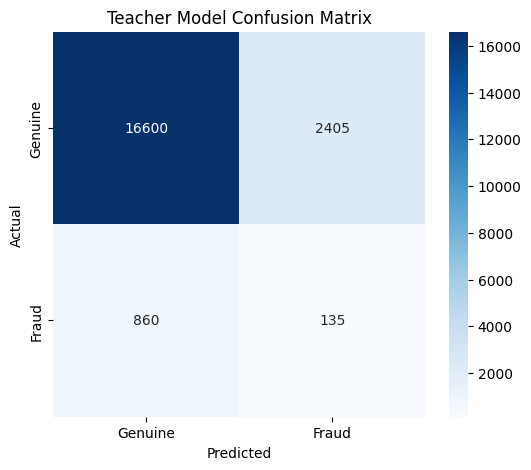

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    teacher_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Teacher Model Confusion Matrix")
plt.show()

In [26]:
#Generate teacher soft label
teacher_train_prob = teacher.predict_proba(
    X_train_processed
)[:, 1]

print(teacher_train_prob[:10])

[0.33994848 0.33899572 0.48772836 0.24510251 0.472356   0.398203
 0.38441235 0.3707899  0.10325123 0.24374786]


In [27]:
from scipy import sparse
import numpy as np

if sparse.issparse(X_train_processed):
    X_train_dense = X_train_processed.toarray().astype(np.float32)
else:
    X_train_dense = np.asarray(X_train_processed).astype(np.float32)

if sparse.issparse(X_test_processed):
    X_test_dense = X_test_processed.toarray().astype(np.float32)
else:
    X_test_dense = np.asarray(X_test_processed).astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)

teacher_train_prob_np = teacher_train_prob.astype(np.float32)

print("Training shape:", X_train_dense.shape)
print("Testing shape:", X_test_dense.shape)
type(X_train_processed)

Training shape: (80000, 93)
Testing shape: (20000, 93)


numpy.ndarray

In [28]:
import numpy as np
# Convert data into PyTorch
X_train_dense = np.asarray(X_train_processed).astype(np.float32)
X_test_dense = np.asarray(X_test_processed).astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)

teacher_train_prob_np = teacher_train_prob.astype(np.float32)

print("X_train:", X_train_dense.shape)
print("X_test :", X_test_dense.shape)

print("y_train:", y_train_np.shape)
print("y_test :", y_test_np.shape)

X_train: (80000, 93)
X_test : (20000, 93)
y_train: (80000,)
y_test : (20000,)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# STUDENT TRAINING DATA
X_train_tensor = torch.tensor(
    X_train_dense,
    dtype=torch.float32
).clone().detach()

y_train_tensor = torch.tensor(
    y_train_np,
    dtype=torch.float32
).clone().detach()

teacher_train_prob_tensor = torch.tensor(
    teacher_train_prob_np,
    dtype=torch.float32
).clone().detach()

# Create dataset
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
    teacher_train_prob_tensor
)

# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

# Check sizes
print("X training:", X_train_tensor.shape)
print("Y training:", y_train_tensor.shape)
print("Teacher probabilities:", teacher_train_prob_tensor.shape)
print("Total training samples:", len(train_dataset))

In [ ]:
input_size = X_train_dense.shape[1]

class StudentModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


student = StudentModel(input_size)

print(student)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

student = student.to(device)

In [ ]:
#Knowledge Distillation
temperature = 4.0
alpha = 0.5

optimizer = torch.optim.Adam(
    student.parameters(),
    lr=0.001
)

hard_loss_function = nn.BCEWithLogitsLoss()

In [ ]:
#Train student using Distillation
epochs = 15

student.train()

for epoch in range(epochs):

    total_loss = 0

    for batch_X, batch_y, batch_teacher_prob in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        batch_teacher_prob = batch_teacher_prob.to(device)

        optimizer.zero_grad()

        # Student prediction
        student_logits = student(batch_X)

        # 1. Hard-label loss
        hard_loss = hard_loss_function(
            student_logits,
            batch_y
        )


        # 2. Soft-label loss
        # Prevent log(0)
        eps = 1e-7

        teacher_logits = torch.log(
            (batch_teacher_prob + eps) /
            (1 - batch_teacher_prob + eps)
        )

        teacher_soft = torch.sigmoid(
            teacher_logits / temperature
        )

        student_soft = torch.sigmoid(
            student_logits / temperature
        )

        soft_loss = nn.functional.binary_cross_entropy(
            student_soft,
            teacher_soft
        )


        # 3. Combined loss
        loss = (
            alpha * hard_loss
            +
            (1 - alpha)
            * soft_loss
            * (temperature ** 2)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss / len(train_loader)
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )

In [ ]:
#Test the student model
X_test_tensor = torch.tensor(
    X_test_dense,
    dtype=torch.float32
).to(device)

In [ ]:
student.eval()

with torch.no_grad():

    student_logits = student(
        X_test_tensor
    )

    student_prob = torch.sigmoid(
        student_logits
    ).cpu().numpy()

In [ ]:
student_pred = (
    student_prob >= 0.5
).astype(int)

In [ ]:
#Evaluate Student
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

student_accuracy = accuracy_score(
    y_test_np,
    student_pred
)

student_precision = precision_score(
    y_test_np,
    student_pred,
    zero_division=0
)

student_recall = recall_score(
    y_test_np,
    student_pred,
    zero_division=0
)

student_f1 = f1_score(
    y_test_np,
    student_pred,
    zero_division=0
)

student_auc = roc_auc_score(
    y_test_np,
    student_prob
)

print("========== STUDENT MODEL ==========")
print(f"Accuracy : {student_accuracy:.4f}")
print(f"Precision: {student_precision:.4f}")
print(f"Recall   : {student_recall:.4f}")
print(f"F1 Score : {student_f1:.4f}")
print(f"ROC-AUC  : {student_auc:.4f}")

In [ ]:
#Compare Teacher vs Student
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Teacher": [
        teacher_accuracy,
        teacher_precision,
        teacher_recall,
        teacher_f1,
        teacher_auc
    ],

    "Student": [
        student_accuracy,
        student_precision,
        student_recall,
        student_f1,
        student_auc
    ]
})

comparison

In [ ]:
#Student Confusion Matrix
cm_student = confusion_matrix(
    y_test_np,
    student_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_student,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Student Model - Confusion Matrix")

plt.show()

In [ ]:
#Automatic Claim Routing
def route_claim(probability):

    if probability <= 0.30:
        return "Fast-Track Payout"

    elif probability <= 0.70:
        return "Standard Review"

    else:
        return "Fraud Investigation"

#now print
print(route_claim(0.15))
print(route_claim(0.55))
print(route_claim(0.90))

In [ ]:
#Apply Routing to Test Claims
results = X_test.copy()

results["Actual_Fraud"] = y_test.values

results["Fraud_Probability"] = student_prob

results["Routing_Decision"] = [
    route_claim(prob)
    for prob in student_prob
]

results.head()

In [ ]:
#Check Routing Distribution
print(
    results["Routing_Decision"].value_counts()
)



In [ ]:
#in graph
plt.figure(figsize=(8,5))

sns.countplot(
    data=results,
    x="Routing_Decision"
)

plt.title("Automatic Insurance Claim Routing")
plt.xlabel("Routing Decision")
plt.ylabel("Number of Claims")

plt.xticks(rotation=20)

plt.show()

In [ ]:
#Test One New Claim
sample_claim = X_test.iloc[[43]].copy()
sample_claim

#Preprocess it:
sample_processed = preprocessor.transform(
    sample_claim
)

sample_dense = np.asarray(
    sample_processed
).astype(np.float32)

#Convert to tensor:
sample_tensor = torch.tensor(
    sample_dense,
    dtype=torch.float32
).to(device)

#Predict:
student.eval()

with torch.no_grad():
    logits = student(
        sample_tensor
    )
    probability = torch.sigmoid(
        logits
    ).item()

    #Routing:
    decision = route_claim(
    probability
)

print(
    f"Fraud Probability: {probability:.2%}"
)

print(
    f"Routing Decision: {decision}"
)